In [ ]:
# 1. IMPORT LIBRARIES

In [ ]:
# Data handling and calculations
import pandas as pd  # For loading and managing dataset
import numpy as np   # For numerical operations

In [ ]:
# Data visualization
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced plots (heatmap, etc.)

In [ ]:
# Preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Scaling and encoding
from sklearn.model_selection import train_test_split  # Split data into train/test

In [ ]:
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Statistics
from scipy import stats

# File handling
import pickle
import warnings


In [ ]:
# 2. UPLOAD AND LOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving music_genre_spectral_features_large.csv to music_genre_spectral_features_large.csv


In [ ]:
df = pd.read_csv("music_genre_spectral_features_large.csv")

In [ ]:
# 3. DATA EXPLORATION (EDA)

In [ ]:
# Display first 5 rows
print(df.head())

              filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0      disco.00001.wav    2949          0.515376         0.047690  0.190360   
1       jazz.00086.wav    3059          0.479535         0.047985  0.130811   
2       jazz.00153.wav    3049          0.606390         0.048378  0.115591   
3    country.00055.wav    2961          0.364671         0.073027  0.131518   
4  classical.00205.wav    2822          0.462103         0.056123  0.084634   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.019285             2339.518225             209.781355   
1  0.008393             1862.507987             227.525354   
2  0.008397             1681.569907             137.461054   
3  0.016404             1759.179928             226.016068   
4  0.003101             1392.388342              86.022726   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              3279.592710              391.336546  ...    2.169504   
1         

In [ ]:
# Display last 5 rows
print(df.tail())

                 filename  length  chroma_stft_mean  chroma_stft_var  \
4995     reggae.00426.wav    3136          0.498679         0.050410   
4996      blues.00466.wav    2922          0.438667         0.048206   
4997      metal.00092.wav    2914          0.339066         0.043863   
4998        pop.00272.wav    2878          0.533734         0.062755   
4999  classical.00360.wav    3025          0.393845         0.052451   

      rms_mean   rms_var  spectral_centroid_mean  spectral_centroid_var  \
4995  0.135520  0.012572             2196.342598              51.216307   
4996  0.138484  0.012176             1599.572324             109.556129   
4997  0.308272  0.027147             2937.499975             373.255384   
4998  0.213616  0.023830             2434.141306             235.105276   
4999  0.083101  0.017313             1450.129967             210.745564   

      spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
4995              1848.937657             

In [ ]:
# Check shape of dataset
df.shape

(5000, 62)

In [ ]:
# Check data types
df.dtypes

,0
filename,object
length,int64
chroma_stft_mean,float64
chroma_stft_var,float64
rms_mean,float64
...,...
mfcc19_mean,float64
mfcc19_var,float64
mfcc20_mean,float64
mfcc20_var,float64


In [ ]:
# Complete information about dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 5000 non-null   object 
 1   length                   5000 non-null   int64  
 2   chroma_stft_mean         5000 non-null   float64
 3   chroma_stft_var          5000 non-null   float64
 4   rms_mean                 5000 non-null   float64
 5   rms_var                  5000 non-null   float64
 6   spectral_centroid_mean   5000 non-null   float64
 7   spectral_centroid_var    5000 non-null   float64
 8   spectral_bandwidth_mean  5000 non-null   float64
 9   spectral_bandwidth_var   5000 non-null   float64
 10  rolloff_mean             5000 non-null   float64
 11  rolloff_var              5000 non-null   float64
 12  zero_crossing_rate_mean  5000 non-null   float64
 13  zero_crossing_rate_var   5000 non-null   float64
 14  harmony_mean            

In [ ]:
# Statistical summary
print(df.describe())

            length  chroma_stft_mean  chroma_stft_var     rms_mean  \
count  5000.000000       5000.000000      5000.000000  5000.000000   
mean   2999.999200          0.458062         0.049765     0.163482   
std     114.206293          0.068940         0.010157     0.063131   
min    2800.000000          0.247504         0.015690     0.020202   
25%    2900.000000          0.409462         0.042872     0.116464   
50%    3001.000000          0.457237         0.049644     0.153307   
75%    3097.000000          0.505239         0.056580     0.204660   
max    3199.000000          0.693974         0.087775     0.357439   

           rms_var  spectral_centroid_mean  spectral_centroid_var  \
count  5000.000000             5000.000000            5000.000000   
mean      0.016397             2189.905939             219.397986   
std       0.007954              533.271467              73.252535   
min       0.000062              846.709939               4.254793   
25%       0.010421      

In [ ]:
# Check for missing values
print(df.isnull().sum())

filename            0
length              0
chroma_stft_mean    0
chroma_stft_var     0
rms_mean            0
                   ..
mfcc19_mean         0
mfcc19_var          0
mfcc20_mean         0
mfcc20_var          0
label               0
Length: 62, dtype: int64


In [ ]:

# Label Encoding - Convert text genres to numbers
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [ ]:
# 4. DATA VISUALIZATION

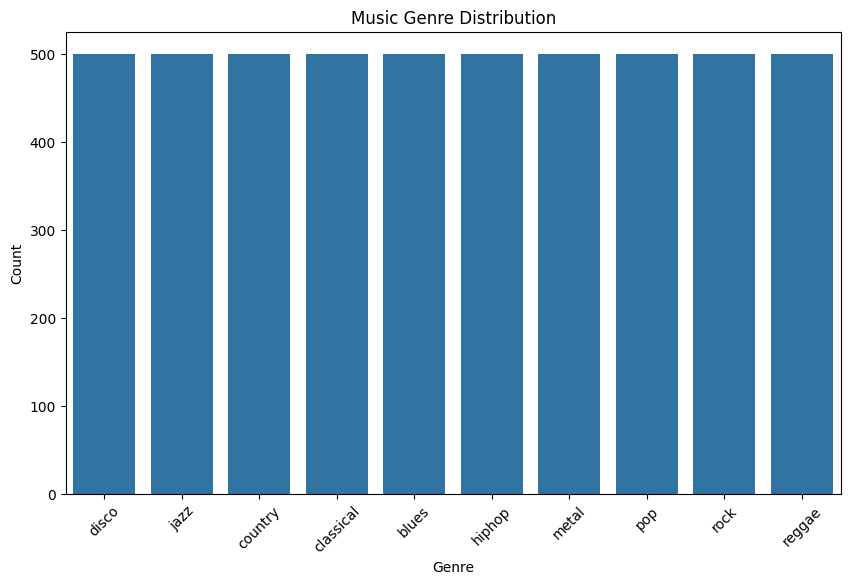

In [ ]:
# Distribution of music genres (bar plot)
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df)
plt.title('Music Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

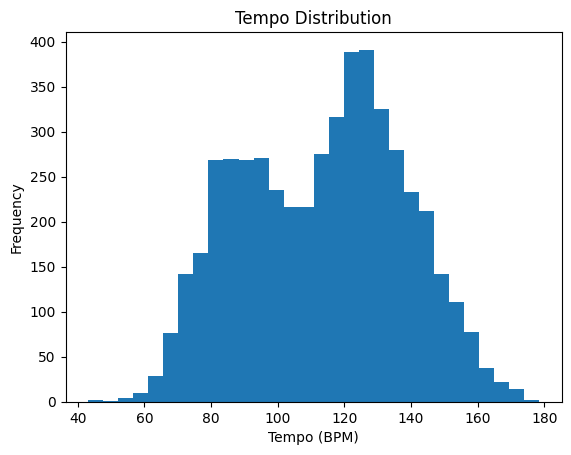

In [ ]:
# 4.2 Histogram for tempo distribution
plt.hist(df['tempo'], bins=30)
plt.title('Tempo Distribution')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Frequency')
plt.show()

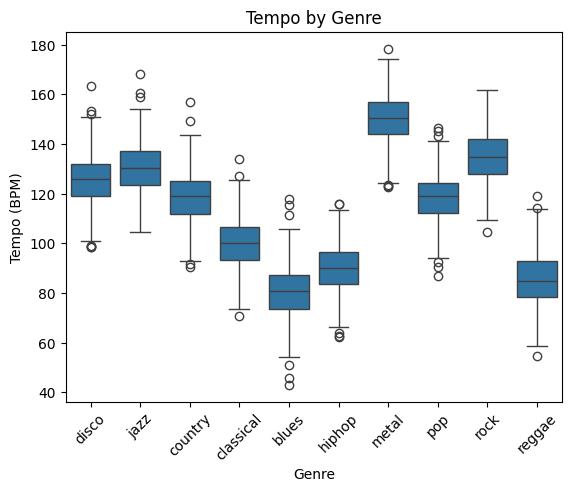

In [ ]:
# 4.3 Boxplot for tempo by genre
sns.boxplot(x='label', y='tempo', data=df)
plt.title('Tempo by Genre')
plt.xlabel('Genre')
plt.ylabel('Tempo (BPM)')
plt.xticks(rotation=45)
plt.show()

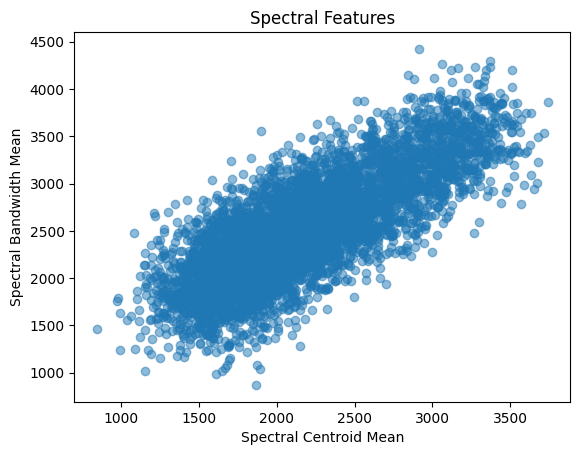

In [ ]:
# 4.4 Scatter plot: Spectral Centroid vs Spectral Bandwidth
plt.scatter(df['spectral_centroid_mean'], df['spectral_bandwidth_mean'], alpha=0.5)
plt.xlabel('Spectral Centroid Mean')
plt.ylabel('Spectral Bandwidth Mean')
plt.title('Spectral Features')
plt.show()

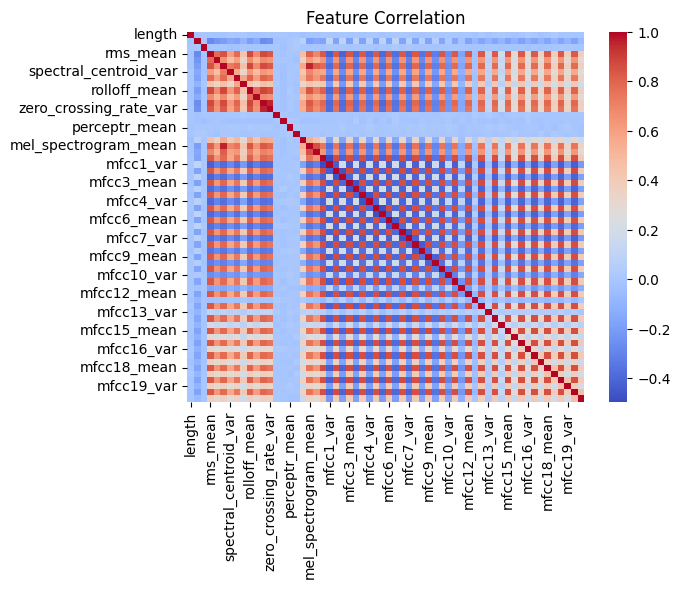

In [ ]:
# 4.5 Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

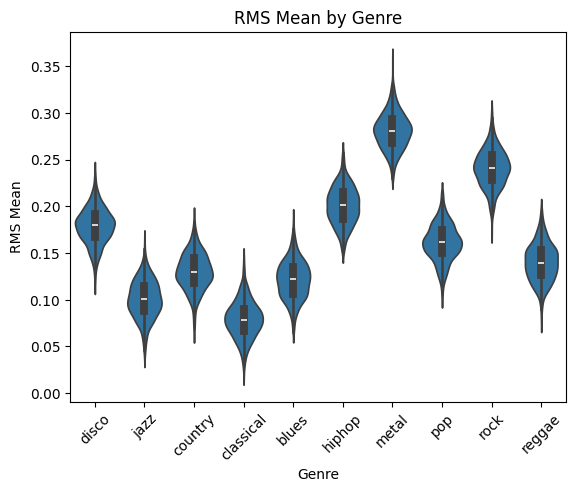

In [ ]:
# 4.6 Violin plot for RMS mean by genre
sns.violinplot(x='label', y='rms_mean', data=df)
plt.title('RMS Mean by Genre')
plt.xlabel('Genre')
plt.ylabel('RMS Mean')
plt.xticks(rotation=45)
plt.show()

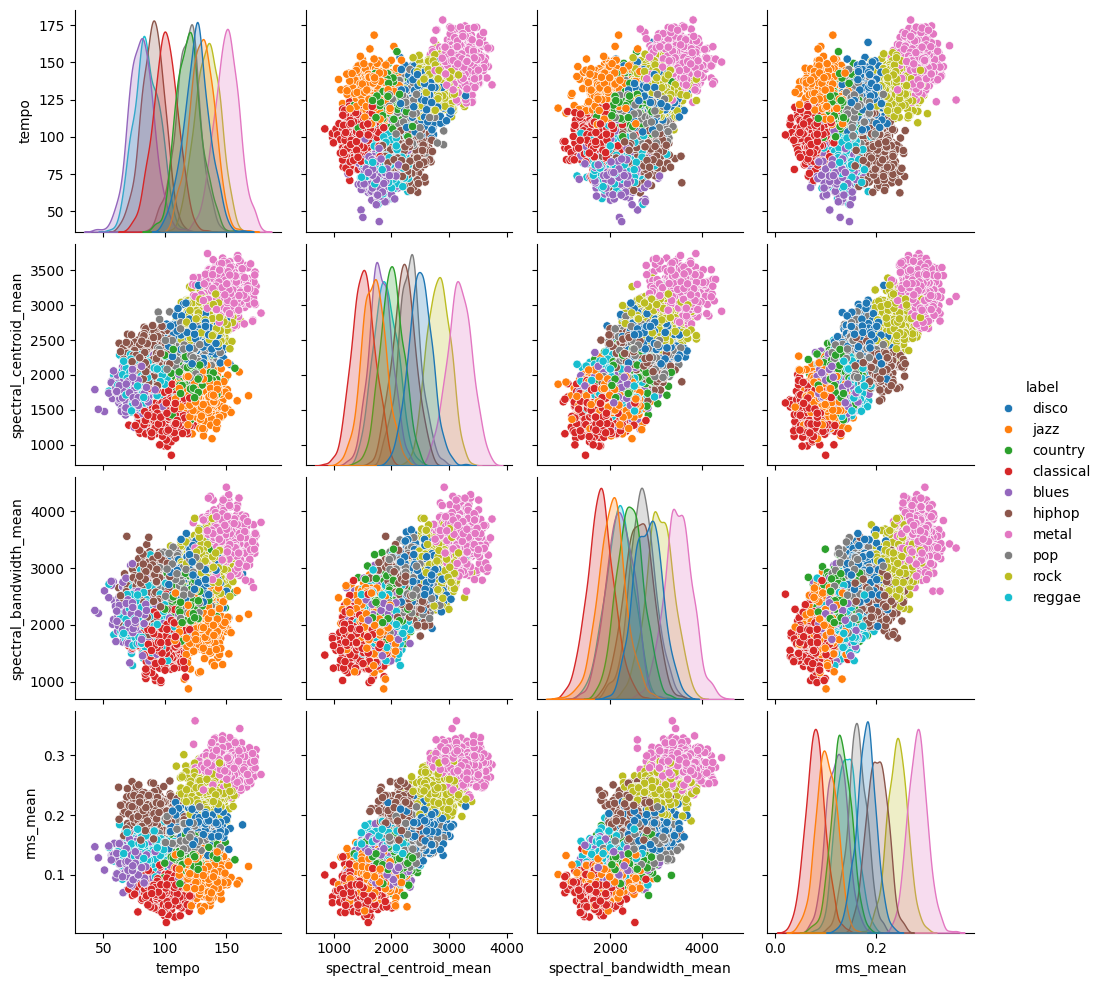

In [ ]:
# 4.7 Pairplot for selected features
selected = ['tempo', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'rms_mean', 'label']
sns.pairplot(df[selected], hue='label')
plt.show()

In [ ]:
# 5. DESCRIPTIVE STATISTICS

In [ ]:
# Calculate statistics for tempo
data = df['tempo']
print(f"\nStatistics for Tempo Feature:")
print(f"Mean: {data.mean():.4f}")
print(f"Median: {data.median():.4f}")
print(f"Mode: {data.mode()[0]:.4f}")
print(f"Variance: {data.var():.4f}")
print(f"Standard Deviation: {data.std():.4f}")
print(f"Range: {data.max() - data.min():.4f}")
print(f"Min Value: {data.min():.4f}")
print(f"Max Value: {data.max():.4f}")


Statistics for Tempo Feature:
Mean: 113.4592
Median: 116.0172
Mode: 43.1147
Variance: 590.1849
Standard Deviation: 24.2937
Range: 135.3033
Min Value: 43.1147
Max Value: 178.4179


In [ ]:
# Calculate Q1, Q3, IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
print(f"Q1 (25th percentile): {Q1:.4f}")
print(f"Q3 (75th percentile): {Q3:.4f}")
print(f"IQR (Interquartile Range): {IQR:.4f}")

Q1 (25th percentile): 92.8925
Q3 (75th percentile): 131.5990
IQR (Interquartile Range): 38.7065


In [ ]:
# Statistics for all numeric features
print(df[numeric_cols].describe())

            length  chroma_stft_mean  chroma_stft_var     rms_mean  \
count  5000.000000       5000.000000      5000.000000  5000.000000   
mean   2999.999200          0.458062         0.049765     0.163482   
std     114.206293          0.068940         0.010157     0.063131   
min    2800.000000          0.247504         0.015690     0.020202   
25%    2900.000000          0.409462         0.042872     0.116464   
50%    3001.000000          0.457237         0.049644     0.153307   
75%    3097.000000          0.505239         0.056580     0.204660   
max    3199.000000          0.693974         0.087775     0.357439   

           rms_var  spectral_centroid_mean  spectral_centroid_var  \
count  5000.000000             5000.000000            5000.000000   
mean      0.016397             2189.905939             219.397986   
std       0.007954              533.271467              73.252535   
min       0.000062              846.709939               4.254793   
25%       0.010421      

In [ ]:
# 6. CONFIDENCE INTERVAL

In [ ]:
# Function to calculate confidence interval
def confidence_interval(data):
    return stats.t.interval(0.95, len(data)-1, loc=data.mean(), scale=stats.sem(data))

print(f"Tempo CI: {confidence_interval(df['tempo'])}")

Tempo CI: (np.float64(112.78561315754929), np.float64(114.13268972645069))


In [ ]:
# 7. HYPOTHESIS TESTING

In [ ]:
# One sample t-test for tempo (testing if mean tempo = 120 BPM)
t_stat, p_value = stats.ttest_1samp(data, popmean=120)
print(f"\nOne Sample T-Test for Tempo (Population Mean = 120):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")


One Sample T-Test for Tempo (Population Mean = 120):
t-statistic: -19.0382
p-value: 0.0000


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: The mean tempo is significantly different from 120 BPM")

else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: The mean tempo is not significantly different from 120 BPM")

Result: Reject Null Hypothesis
Conclusion: The mean tempo is significantly different from 120 BPM


In [ ]:
# 8. DATA PREPROCESSING

In [ ]:
# Drop filename column (FIX FOR THE ERROR)
df = df.drop(columns=['filename'])
print("Dropped 'filename' column")

Dropped 'filename' column


In [ ]:
# Separate features and target
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

In [ ]:
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (5000, 60)
Target shape: (5000,)


In [ ]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 4000, Test size: 1000


In [ ]:
# 9. TRAIN MODELS

In [ ]:
# Train models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # SABHI METRICS CALCULATE KARO
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append([name, acc, pre, rec, f1])
    print(f"{name}: Acc={acc:.4f}, Pre={pre:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

# TABLE 
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(results_df.to_string(index=False))

In [ ]:
trained_models = {}
results = []

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9280
Decision Tree: 0.8130
Random Forest: 0.9180
SVM: 0.9410
KNN: 0.8000


In [ ]:
# 10. RESULTS TABLE

                 Model  Accuracy
0  Logistic Regression     0.928
1        Decision Tree     0.813
2        Random Forest     0.918
3                  SVM     0.941
4                  KNN     0.800


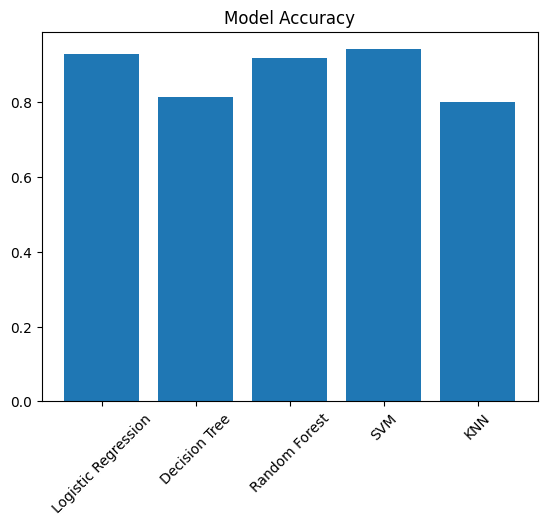

In [ ]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
print(results_df)

# Bar chart
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=45)
plt.title('Model Accuracy')
plt.show()

In [ ]:
# 11. BEST MODEL

In [ ]:
best_model = trained_models[results_df.loc[results_df['Accuracy'].idxmax(), 'Model']]
print(f"Best Model: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']}")
print(f"Accuracy: {results_df['Accuracy'].max():.4f}")

Best Model: SVM
Accuracy: 0.9410


In [ ]:
# 12. CONFUSION MATRIX

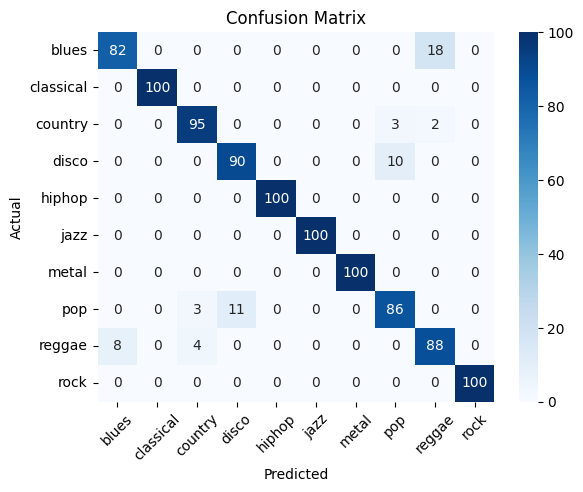

In [ ]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 13. SAVE FILES

In [ ]:
pickle.dump(best_model, open('music_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))